# SetUp

In [1]:
import sys
from pathlib import Path
sys.path.append(Path.cwd().parent.parent.joinpath("src").as_posix())

print(sys.path[-1])
# for p in sys.path:
#   print(p)

DATA_PATH = Path.cwd().parent.parent.joinpath("data/keras")
print(f"DATA_PATH={DATA_PATH}")


import PIL
import numpy as np
import matplotlib.pyplot as plt

print(PIL.__version__)
print(np.__version__)
import matplotlib
print(matplotlib.__version__)

d:/workspace/github/hack-modeling/ml/codes/hands-on-ml/src
DATA_PATH=d:\workspace\github\hack-modeling\ml\codes\hands-on-ml\data\keras
11.3.0
2.3.2
3.10.6


# geometric operation
* https://pillow.readthedocs.io/en/latest/handbook/tutorial.html#geometrical-transforms
* Deep Learning with Python - 2.3.5 Geometric interpretation of tensor operations

operations
- translation: add a vector
- rotation
- scaling
- linear transform = scaling + rotation
- affine transform = linear transform + translation
- dense layer with relu activation

In [2]:
from PIL import Image

logo_file = DATA_PATH.joinpath("keras-logo.png")
img = Image.open(logo_file)

# img_data = list(img.getdata())
# a = np.array(img_data)
# a = a.reshape(*img.size)
# a.ndim, a.shape, a.dtype, a[0][0]
a = np.asarray(img)

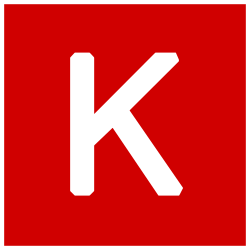

In [3]:
img.convert('RGBA')

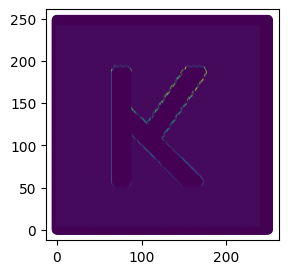

In [4]:
%matplotlib inline
# https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.imshow.html
# plt.imshow(a)
# plt.show()

xsize, ysize = img.size
z = np.zeros((xsize, ysize))
xs = []
ys = []
zs = []
for x in range(xsize):
  for y in range(ysize):
    xs.append(x)
    ys.append(y)
    zs.append(a[y,x])


def plot_logo(xs, ys, zs):
  fig, ax = plt.subplots(figsize=(3, 3))
  ax.scatter(xs,ys,c=zs)
  # ax.set_xlim(xmin=-300, xmax=300)
  # ax.set_ylim(ymin=-300, ymax=300)
  plt.show()

plot_logo(xs, ys, zs)

## translation

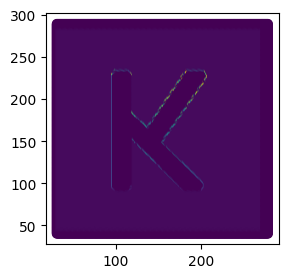

In [5]:
xs2 = xs + np.array(30)
ys2 = ys + np.array(40)

plot_logo(xs2, ys2, zs)

## rotation

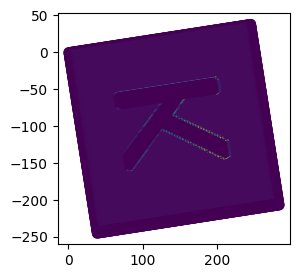

In [6]:
theta = 30
R = [[np.cos(theta), -np.sin(theta)], 
     [np.sin(theta), np.cos(theta)]]

xys = np.dot(R, np.vstack((xs, ys)))
plot_logo(xys[0], xys[1], zs)

## scaling

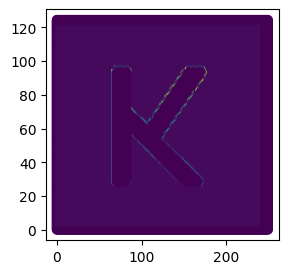

In [7]:
h_factor = 1
v_factor = 0.5
S = [[h_factor, 0], [0, v_factor]]

xys = np.dot(S, np.vstack((xs, ys)))
plot_logo(xys[0], xys[1], zs)

## llinear transform = scaling + rotation

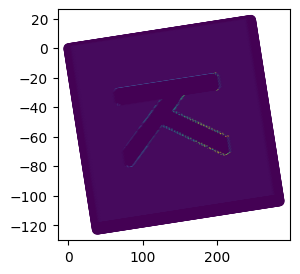

In [8]:
xys = np.dot(S, np.dot(R, np.vstack((xs, ys))))
plot_logo(xys[0], xys[1], zs)

## affine transform

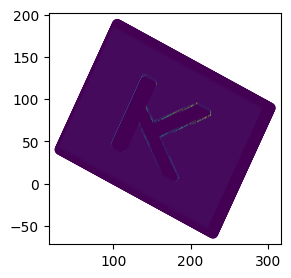

In [9]:
W = [[0.8, 0.3], [-0.4, 0.6]]
b = [[30], [40]]

xys = np.dot(W, np.vstack((xs, ys))) + np.array(b)
plot_logo(xys[0], xys[1], zs)

## dense layer with relu activation

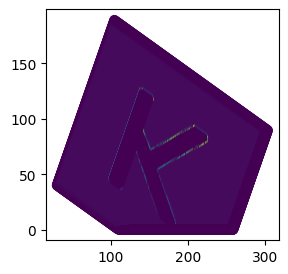

In [10]:
W = [[0.8, 0.3], [-0.4, 0.6]]
b = [[30], [40]]

xys = np.dot(W, np.vstack((xs, ys))) + np.array(b)
plot_logo(xys[0], np.maximum(xys[1], 0), zs)